In [1]:
import numpy as np
from keras import models, layers
from keras.datasets import imdb

(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000)

def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.
    return results

x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)
y_train = np.asarray(train_labels).astype("float32")
y_test = np.asarray(test_labels).astype("float32")

model = models.Sequential()
model.add(layers.Dense(16, activation="relu", input_shape=(10000,)))
model.add(layers.Dense(16, activation="relu"))
model.add(layers.Dense(1, activation="sigmoid"))

model.compile(optimizer="rmsprop",
              loss="binary_crossentropy",
              metrics=["accuracy"])

x_val = x_train[:10000]
partial_x_train = x_train[10000:]
y_val = y_train[:10000]
partial_y_train = y_train[10000:]

history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

results = model.evaluate(x_test, y_test)


C:\Users\thaca\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 62ms/step - accuracy: 0.7637 - loss: 0.5345 - val_accuracy: 0.8225 - val_loss: 0.4281
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8943 - loss: 0.3196 - val_accuracy: 0.8822 - val_loss: 0.3075
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9183 - loss: 0.2378 - val_accuracy: 0.8911 - val_loss: 0.2795
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9341 - loss: 0.1930 - val_accuracy: 0.8900 - val_loss: 0.2736
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9495 - loss: 0.1576 - val_accuracy: 0.8856 - val_loss: 0.2856
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9551 - loss: 0.1361 - val_accuracy: 0.8865 - val_loss: 0.2879
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9640 - loss: 0.1140 - val_accuracy: 0.8843 - val_loss: 0.3011
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9683 - loss: 0.1015 - val_accuracy: 0.8810 - v

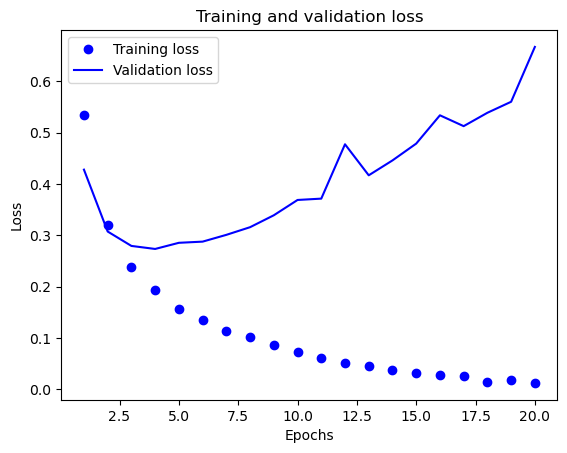

In [2]:
import matplotlib.pyplot as plt
history_dict = history.history
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]

epochs = range(1, len(loss_values) + 1)

plt.plot(epochs, loss_values, "bo", label="Training loss")
plt.plot(epochs, val_loss_values, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

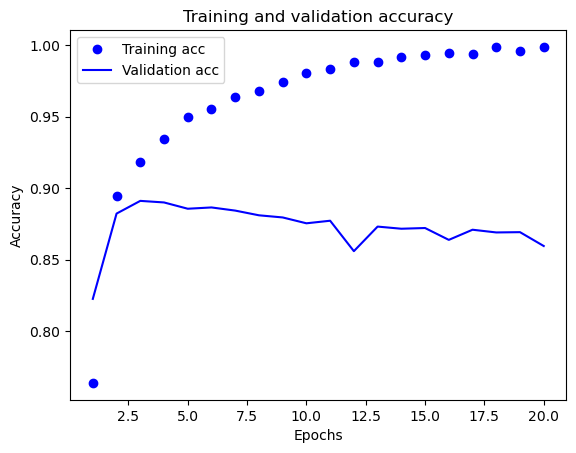

In [3]:
plt.clf()   # Clears the figure

acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]

plt.plot(epochs, acc, "bo", label="Training acc")
plt.plot(epochs, val_acc, "b", label="Validation acc")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [6]:
import numpy as np
import tensorflow as tf
from keras.datasets import imdb

# ---------- Data ----------
NUM_WORDS = 10000
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=NUM_WORDS)

def vectorize_sequences(sequences, dimension=NUM_WORDS):
    results = np.zeros((len(sequences), dimension), dtype="float32")
    for i, seq in enumerate(sequences):
        results[i, seq] = 1.0
    return results

x_train = vectorize_sequences(train_data)
x_test  = vectorize_sequences(test_data)
y_train = np.asarray(train_labels, dtype="float32")
y_test  = np.asarray(test_labels,  dtype="float32")

x_val = x_train[:10000]
y_val = y_train[:10000]
partial_x_train = x_train[10000:]
partial_y_train = y_train[10000:]

# ---------- MLP model ----------
class MLPBinaryClassifier:
    def __init__(self, input_dim, h1=16, h2=16, lr=1e-3):
        g = tf.random.Generator.from_seed(42)
        self.W1 = tf.Variable(g.normal([input_dim, h1]) * 0.05)
        self.b1 = tf.Variable(tf.zeros([h1]))
        self.W2 = tf.Variable(g.normal([h1, h2]) * 0.05)
        self.b2 = tf.Variable(tf.zeros([h2]))
        self.W3 = tf.Variable(g.normal([h2, 1]) * 0.05)
        self.b3 = tf.Variable(tf.zeros([1]))
        self.opt = tf.optimizers.Adam(lr)

    def forward(self, x):
        z1 = tf.matmul(x, self.W1) + self.b1
        a1 = tf.nn.relu(z1)
        z2 = tf.matmul(a1, self.W2) + self.b2
        a2 = tf.nn.relu(z2)
        logits = tf.matmul(a2, self.W3) + self.b3
        return logits

    def loss(self, y_true, logits):
        y_true = tf.reshape(y_true, (-1, 1))
        return tf.reduce_mean(tf.nn.sigmoid_cross_entropy_with_logits(labels=y_true, logits=logits))

    def accuracy(self, y_true, logits):
        probs = tf.sigmoid(logits)
        preds = tf.cast(probs >= 0.5, tf.float32)
        y_true = tf.reshape(y_true, (-1, 1))
        return tf.reduce_mean(tf.cast(tf.equal(preds, y_true), tf.float32))

# ---------- Training Loop ----------
model = MLPBinaryClassifier(NUM_WORDS)
EPOCHS = 20
BATCH_SIZE = 512

train_dataset = tf.data.Dataset.from_tensor_slices((partial_x_train, partial_y_train))
train_dataset = train_dataset.shuffle(len(partial_x_train)).batch(BATCH_SIZE)

val_dataset = tf.data.Dataset.from_tensor_slices((x_val, y_val)).batch(BATCH_SIZE)

for epoch in range(EPOCHS):
    # training
    epoch_loss = tf.metrics.Mean()
    epoch_acc  = tf.metrics.Mean()
    for xb, yb in train_dataset:
        with tf.GradientTape() as tape:
            logits = model.forward(xb)
            loss = model.loss(yb, logits)
        grads = tape.gradient(loss, [model.W1, model.b1, model.W2, model.b2, model.W3, model.b3])
        model.opt.apply_gradients(zip(grads, [model.W1, model.b1, model.W2, model.b2, model.W3, model.b3]))
        epoch_loss.update_state(loss)
        epoch_acc.update_state(model.accuracy(yb, logits))

    # validation
    val_loss = tf.metrics.Mean()
    val_acc  = tf.metrics.Mean()
    for xb, yb in val_dataset:
        logits = model.forward(xb)
        val_loss.update_state(model.loss(yb, logits))
        val_acc.update_state(model.accuracy(yb, logits))

    print(f"Epoch {epoch+1}: "
          f"Train Loss={epoch_loss.result():.4f}, Train Acc={epoch_acc.result():.4f}, "
          f"Val Loss={val_loss.result():.4f}, Val Acc={val_acc.result():.4f}")


Epoch 1: Train Loss=0.6775, Train Acc=0.6857, Val Loss=0.6396, Val Acc=0.7758
Epoch 2: Train Loss=0.5385, Train Acc=0.8368, Val Loss=0.4355, Val Acc=0.8497
Epoch 3: Train Loss=0.3278, Train Acc=0.8884, Val Loss=0.3075, Val Acc=0.8781
Epoch 4: Train Loss=0.2203, Train Acc=0.9209, Val Loss=0.2789, Val Acc=0.8884
Epoch 5: Train Loss=0.1687, Train Acc=0.9414, Val Loss=0.2784, Val Acc=0.8897
Epoch 6: Train Loss=0.1350, Train Acc=0.9552, Val Loss=0.2915, Val Acc=0.8857
Epoch 7: Train Loss=0.1095, Train Acc=0.9659, Val Loss=0.3056, Val Acc=0.8849
Epoch 8: Train Loss=0.0898, Train Acc=0.9757, Val Loss=0.3257, Val Acc=0.8821
Epoch 9: Train Loss=0.0716, Train Acc=0.9810, Val Loss=0.3477, Val Acc=0.8813
Epoch 10: Train Loss=0.0574, Train Acc=0.9873, Val Loss=0.3728, Val Acc=0.8795
Epoch 11: Train Loss=0.0456, Train Acc=0.9912, Val Loss=0.4007, Val Acc=0.8773
Epoch 12: Train Loss=0.0364, Train Acc=0.9943, Val Loss=0.4291, Val Acc=0.8761
Epoch 13: Train Loss=0.0285, Train Acc=0.9965, Val Loss=0.460